In [1]:
import os
import re
import pickle
import joblib

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import export_text

import matplotlib.pyplot as plt
import seaborn as sns

import gc

In [2]:
df = pd.read_csv("F:/analysis/data/weapons.csv")
df["date"] = pd.to_datetime(df["date"])

cat_cols = ["steam_rarity", "exterior", "weapon", "skin", "collection"]
for col in cat_cols:
    df[col] = df[col].astype("category")

df = df.sort_values(["steam_market_hash_name", "date"])
df["log_price"] = np.log(df["price"])

In [ ]:
temp_for_split = df.sort_values("date")
global_split_date = temp_for_split["date"].iloc[int(len(temp_for_split) * 0.7)]
del temp_for_split
# print(f"Глобальна дата спліта: {global_split_date.date()}")

df_historical = df[df["date"] < global_split_date].copy()
df_historical["logret_1d"] = df_historical.groupby("steam_market_hash_name")["log_price"].diff(1)

In [ ]:
# GATING MODEL
features_dt = df_historical.groupby("steam_market_hash_name").agg(
    mean_liquidity=("liquidity", "mean"),
    mean_volume=("amount", "mean"),
    n_obs=("logret_1d", lambda x: x.notna().sum()),
    n_days=("date", lambda x: (x.max() - x.min()).days + 1),
    max_gap_days=("date", lambda x: x.sort_values().diff().dt.days.max()),
    ar1=("logret_1d", lambda x: x.dropna().autocorr(lag=1) if x.dropna().shape[0] > 2 else np.nan),
    zero_return_frac=("logret_1d", lambda x: (x.dropna() == 0).mean() if x.dropna().shape[0] > 0 else np.nan),
).reset_index()

features_dt["coverage_ratio"] = features_dt["n_obs"] / features_dt["n_days"]
features_dt["pct_gaps_gt7"] = features_dt["max_gap_days"] / features_dt["n_days"]

In [5]:
def baseline_mae_item(g):
    g = g.dropna(subset=["logret_1d"])
    if len(g) < 10:
        return np.nan
    from sklearn.metrics import mean_absolute_error
    y_true = g["logret_1d"].iloc[1:]
    y_pred = g["logret_1d"].shift(1).iloc[1:]
    return mean_absolute_error(y_true, y_pred)

baseline = (df_historical.groupby("steam_market_hash_name")
              .apply(baseline_mae_item)
              .rename("baseline_mae")
              .reset_index())

features_dt = features_dt.merge(baseline, on="steam_market_hash_name", how="left")

In [6]:
DT_FEATURES = ["mean_liquidity", "coverage_ratio", "pct_gaps_gt7",
               "mean_volume", "ar1", "zero_return_frac"]

gate_df = features_dt.dropna(subset=DT_FEATURES + ["baseline_mae"]).copy()
train_df, test_df = train_test_split(gate_df, test_size=0.25, random_state=42)

## Kneedle

In [7]:
# Kneedle на історичному трейні
mae_train = train_df["baseline_mae"].values
sorted_mae = np.sort(mae_train)
cdf = np.arange(1, len(sorted_mae) + 1) / len(sorted_mae)
x_norm = (sorted_mae - sorted_mae.min()) / (sorted_mae.max() - sorted_mae.min())
distance = cdf - x_norm

knee_idx = np.argmax(distance)
MAE_THRESHOLD = sorted_mae[np.argmax(distance)]
knee_pct = cdf[knee_idx]

train_df["forecastable"] = (train_df["baseline_mae"] <= MAE_THRESHOLD).astype(int)
test_df["forecastable"] = (test_df["baseline_mae"] <= MAE_THRESHOLD).astype(int)
gate_df["forecastable"] = (gate_df["baseline_mae"] <= MAE_THRESHOLD).astype(int)

In [8]:
MAE_THRESHOLD

0.41595631382292053

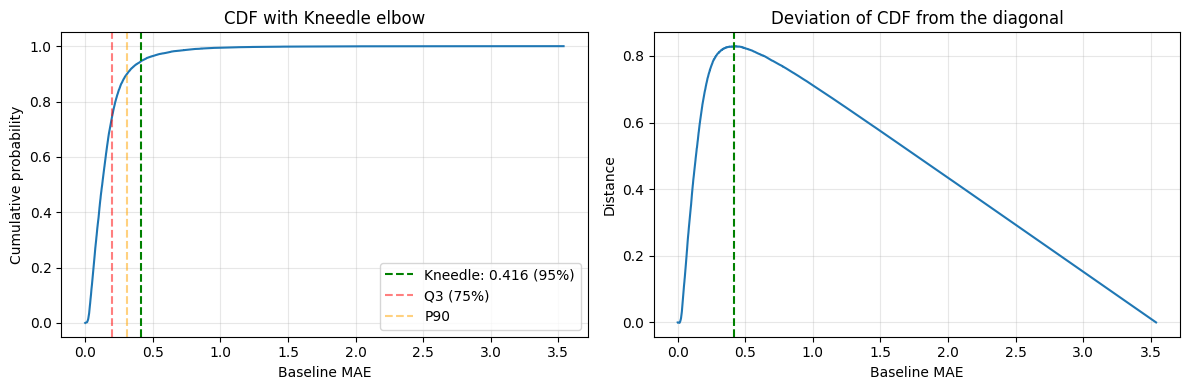

Kneedle elbow: MAE = 0.4160 (percentile: 94.7%)
Q3:            MAE = 0.2005
P90:           MAE = 0.3102
  Kneedle  MAE ≤ 0.416: 9454 items (94.7%)
  Q3       MAE ≤ 0.200: 7488 items (75.0%)
  P90      MAE ≤ 0.310: 8985 items (90.0%)


In [9]:
# Kneedle threshold determination
mae_series = pd.Series(mae_train).dropna()
q3_val = mae_series.quantile(0.75)
p90_val = mae_series.quantile(0.90)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: CDF with Kneedle elbow and reference percentiles
axes[0].plot(sorted_mae, cdf, linewidth=1.5)
axes[0].axvline(MAE_THRESHOLD, color="green", ls="--",
                label=f"Kneedle: {MAE_THRESHOLD:.3f} ({knee_pct:.0%})")
axes[0].axvline(q3_val, color="red", ls="--", alpha=0.5, label="Q3 (75%)")
axes[0].axvline(p90_val, color="orange", ls="--", alpha=0.5, label="P90")
axes[0].set_title("CDF with Kneedle elbow")
axes[0].set_xlabel("Baseline MAE")
axes[0].set_ylabel("Cumulative probability")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: deviation of CDF from the diagonal
axes[1].plot(sorted_mae, distance, linewidth=1.5)
axes[1].axvline(MAE_THRESHOLD, color="green", ls="--")
axes[1].set_title("Deviation of CDF from the diagonal")
axes[1].set_xlabel("Baseline MAE")
axes[1].set_ylabel("Distance")
axes[1].grid(alpha=0.3)

plt.tight_layout()
save_path = "F:/analysis/models_data/fig_5_1_kneedle_threshold.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Kneedle elbow: MAE = {MAE_THRESHOLD:.4f} (percentile: {knee_pct:.1%})")
print(f"Q3:            MAE = {q3_val:.4f}")
print(f"P90:           MAE = {p90_val:.4f}")

for label, thr in [("Kneedle", MAE_THRESHOLD), ("Q3", q3_val), ("P90", p90_val)]:
    n = (mae_series <= thr).sum()
    pct = n / len(mae_series) * 100
    print(f"  {label:8s} MAE ≤ {thr:.3f}: {n} items ({pct:.1f}%)")

In [ ]:
best_dt = DecisionTreeClassifier(max_depth=4, min_samples_leaf=30, class_weight="balanced", random_state=42)
best_dt.fit(train_df[DT_FEATURES], train_df["forecastable"])

proba_dt = best_dt.predict_proba(gate_df[DT_FEATURES])[:, 1]

pools = {
    "1. 100% Даних": df_historical["steam_market_hash_name"].unique(),
    "2. Kneedle (MAE <= 0.416)": gate_df[gate_df["forecastable"] == 1]["steam_market_hash_name"].values,
    "3. DT Фільтр (t=0.5)": gate_df[proba_dt >= 0.5]["steam_market_hash_name"].values,
    "4. DT Фільтр (t=0.7)": gate_df[proba_dt >= 0.7]["steam_market_hash_name"].values
}

## ENN

In [11]:
scaler_is = StandardScaler()
X_scaled_is = scaler_is.fit_transform(train_df[DT_FEATURES])  # train_df від Gating split

knn_is = KNeighborsClassifier(n_neighbors=5)
knn_is.fit(X_scaled_is, train_df["forecastable"].values)
enn_mask = (train_df["forecastable"].values == knn_is.predict(X_scaled_is))
train_enn = train_df[enn_mask].copy()

dt_enn = DecisionTreeClassifier(max_depth=4, min_samples_leaf=30, 
                                 class_weight="balanced", random_state=42)
dt_enn.fit(train_enn[DT_FEATURES], train_enn["forecastable"])
proba_enn = dt_enn.predict_proba(gate_df[DT_FEATURES])[:, 1]

print(f"ENN: видалено {(~enn_mask).sum()} з {len(train_df)} тренувальних предметів")

ENN: видалено 442 з 9984 тренувальних предметів


## RENN

In [12]:
X_renn = X_scaled_is.copy()
y_renn = train_df["forecastable"].values.copy()
mask_renn = np.ones(len(y_renn), dtype=bool)

for iteration in range(10):
    knn_r = KNeighborsClassifier(n_neighbors=5)
    knn_r.fit(X_renn[mask_renn], y_renn[mask_renn])
    preds = knn_r.predict(X_renn[mask_renn])
    new_mask = (y_renn[mask_renn] == preds)
    
    removed = (~new_mask).sum()
    if removed == 0:
        print(f"RENN: зупинка на ітерації {iteration+1} (0 видалено)")
        break
    
    indices = np.where(mask_renn)[0]
    mask_renn[indices[~new_mask]] = False
    print(f"RENN ітерація {iteration+1}: видалено {removed}, залишилось {mask_renn.sum()}")

train_renn = train_df[mask_renn].copy()
dt_renn = DecisionTreeClassifier(max_depth=4, min_samples_leaf=30,
                                  class_weight="balanced", random_state=42)
dt_renn.fit(train_renn[DT_FEATURES], train_renn["forecastable"])
proba_renn = dt_renn.predict_proba(gate_df[DT_FEATURES])[:, 1]

RENN ітерація 1: видалено 442, залишилось 9542
RENN ітерація 2: видалено 49, залишилось 9493
RENN ітерація 3: видалено 12, залишилось 9481
RENN ітерація 4: видалено 2, залишилось 9479
RENN: зупинка на ітерації 5 (0 видалено)


## DROP3 

(спрощена версія — видаляємо якщо сусіди класифікують краще без нас) ===
DROP3 = ENN спочатку (прибираємо шум), потім видаляємо "зайвих"
Повний DROP3 дуже повільний на великих даних, тому працюємо на ENN-очищеному

In [13]:
from sklearn.neighbors import NearestNeighbors


X_d3 = scaler_is.transform(train_enn[DT_FEATURES])
y_d3 = train_enn["forecastable"].values.copy()
n = len(y_d3)

K = 5
nn = NearestNeighbors(n_neighbors=K+1)
nn.fit(X_d3)
_, all_neighbors = nn.kneighbors(X_d3)
all_neighbors = all_neighbors[:, 1:]  # прибрати себе

associates = {i: set() for i in range(n)}
for i in range(n):
    for j in all_neighbors[i]:
        associates[j].add(i)

enemy_dist = []
for i in range(n):
    enemy_dists = [np.linalg.norm(X_d3[i] - X_d3[j]) 
                   for j in all_neighbors[i] if y_d3[j] != y_d3[i]]
    enemy_dist.append(enemy_dists[0] if enemy_dists else np.inf)
order = np.argsort(-np.array(enemy_dist))  # далекі від межі першими

keep = np.ones(n, dtype=bool)
for idx in order:
    if not keep[idx]:
        continue
    all_ok = True
    for assoc in associates[idx]:
        if not keep[assoc]:
            continue
        neighbor_labels = [y_d3[j] for j in all_neighbors[assoc] if keep[j] and j != idx]
        if not neighbor_labels:
            all_ok = False
            break
        vote = int(np.mean(neighbor_labels) >= 0.5)
        if vote != y_d3[assoc]:
            all_ok = False
            break
    if all_ok:
        keep[idx] = False

train_drop3 = train_enn[keep].copy()
print(f"TRUE DROP3: залишилось {keep.sum()} з {n} ({keep.sum()/n*100:.1f}%)")

dt_drop3 = DecisionTreeClassifier(max_depth=4, min_samples_leaf=30,
                                   class_weight="balanced", random_state=42)
dt_drop3.fit(train_drop3[DT_FEATURES], train_drop3["forecastable"])
proba_drop3 = dt_drop3.predict_proba(gate_df[DT_FEATURES])[:, 1]

TRUE DROP3: залишилось 2015 з 9542 (21.1%)


In [14]:
pools["5. ENN (t=0.7)"] = gate_df[proba_enn >= 0.7]["steam_market_hash_name"].values
pools["6. RENN (t=0.7)"] = gate_df[proba_renn >= 0.7]["steam_market_hash_name"].values
pools["7. DROP3 (t=0.7)"] = gate_df[proba_drop3 >= 0.7]["steam_market_hash_name"].values

## RF замість DT для Gating Model

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_gate = RandomForestClassifier(
    n_estimators=200, max_depth=6, min_samples_leaf=20,
    class_weight="balanced", random_state=42, n_jobs=-1
)
rf_gate.fit(train_df[DT_FEATURES], train_df["forecastable"])
proba_rf_gate = rf_gate.predict_proba(gate_df[DT_FEATURES])[:, 1]

pools["8. RF Gating (t=0.7)"] = gate_df[proba_rf_gate >= 0.7]["steam_market_hash_name"].values

In [16]:
for pname, pitems in pools.items():
    print(f"{pname}: {len(pitems)} предметів")

1. 100% Даних: 13823 предметів
2. Kneedle (MAE <= 0.416): 12605 предметів
3. DT Фільтр (t=0.5): 9765 предметів
4. DT Фільтр (t=0.7): 7171 предметів
5. ENN (t=0.7): 11272 предметів
6. RENN (t=0.7): 12160 предметів
7. DROP3 (t=0.7): 11092 предметів
8. RF Gating (t=0.7): 8528 предметів


In [17]:
print("\n" + "=" * 70)
print(f"TEST SET: Порівняння моделей (Поріг t=0.7)")
print("=" * 70)

models_to_eval = {
    "1. Baseline DT": (best_dt, train_df),
    "2. ENN DT": (dt_enn, train_enn),
    "3. RENN DT": (dt_renn, train_renn),
    "4. DROP3 DT": (dt_drop3, train_drop3),
    "5. RF Gating": (rf_gate, train_df)
}

EVAL_THRESHOLD = 0.7
y_test = test_df["forecastable"]
rows = []


for name, (model, train_subset) in models_to_eval.items():
    proba = model.predict_proba(test_df[DT_FEATURES])[:, 1]
    y_pred = (proba >= EVAL_THRESHOLD).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    retention = len(train_subset) / len(train_df) * 100
    
    rows.append({
        "Метод": name, 
        "FP (Шум)": fp, 
        "TP (Чисті)": tp,
        "Пул (Test)": tp + fp, 
        "Precision": f"{prec*100:.2f}%",
        "Train Retention": f"{retention:.1f}%"
    })

eval_df = pd.DataFrame(rows)
print(f"Train Base: {len(train_df)} | Test: {len(test_df)} | Kneedle MAE: {MAE_THRESHOLD:.4f}\n")
print(eval_df.to_string(index=False))


TEST SET: Порівняння моделей (Поріг t=0.7)
Train Base: 9984 | Test: 3328 | Kneedle MAE: 0.4160

         Метод  FP (Шум)  TP (Чисті)  Пул (Test) Precision Train Retention
1. Baseline DT        14        1779        1793    99.22%          100.0%
     2. ENN DT        63        2784        2847    97.79%           95.6%
    3. RENN DT       103        2951        3054    96.63%           94.9%
   4. DROP3 DT        66        2738        2804    97.65%           20.2%
  5. RF Gating        12        2101        2113    99.43%          100.0%


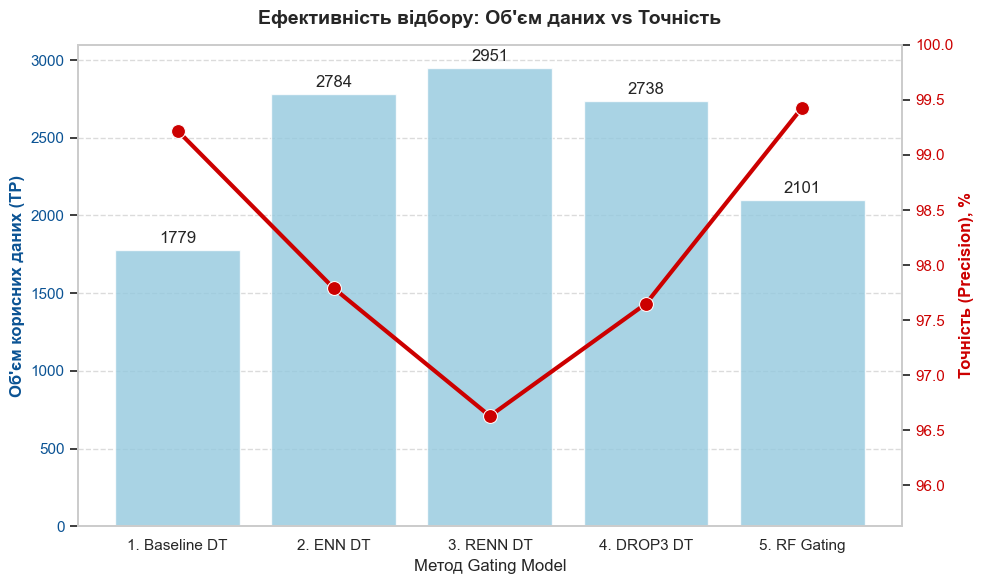

In [18]:
eval_df["Precision_val"] = eval_df["Precision"].str.rstrip('%').astype(float)
eval_df["Retention_val"] = eval_df["Train Retention"].str.rstrip('%').astype(float)

sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(10, 6))

sns.barplot(data=eval_df, x="Метод", y="TP (Чисті)", color="skyblue", ax=ax1, alpha=0.8)
ax1.set_ylabel("Об'єм корисних даних (TP)", color="#0b5394", fontsize=12, fontweight="bold")
ax1.set_xlabel("Метод Gating Model", fontsize=12)
ax1.tick_params(axis='y', labelcolor="#0b5394")
ax1.bar_label(ax1.containers[0], padding=3)

ax2 = ax1.twinx()
sns.lineplot(data=eval_df, x="Метод", y="Precision_val", color="#cc0000", marker="o", ax=ax2, linewidth=3, markersize=10)
ax2.set_ylabel("Точність (Precision), %", color="#cc0000", fontsize=12, fontweight="bold")
ax2.tick_params(axis='y', labelcolor="#cc0000")

ax2.set_ylim(eval_df["Precision_val"].min() - 1, 100)

ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax2.grid(False)

plt.title("Ефективність відбору: Об'єм даних vs Точність", fontsize=14, pad=15, fontweight="bold")
plt.tight_layout()
plt.savefig("F:/analysis/plots/gating_models_comparison.png", dpi=300)
plt.show()

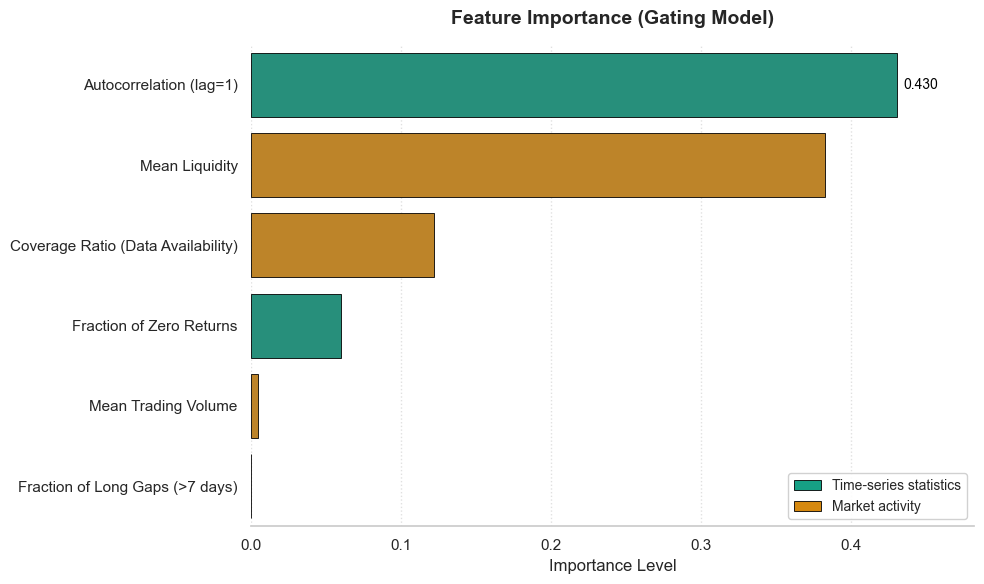

Feature importance (original names):
ar1                 0.430446
mean_liquidity      0.382679
coverage_ratio      0.121816
zero_return_frac    0.060327
mean_volume         0.004733
pct_gaps_gt7        0.000000

Tree rules:
|--- ar1 <= -0.47
|   |--- coverage_ratio <= 0.19
|   |   |--- mean_liquidity <= 4.36
|   |   |   |--- coverage_ratio <= 0.11
|   |   |   |   |--- class: 0
|   |   |   |--- coverage_ratio >  0.11
|   |   |   |   |--- class: 0
|   |   |--- mean_liquidity >  4.36
|   |   |   |--- ar1 <= -0.52
|   |   |   |   |--- class: 0
|   |   |   |--- ar1 >  -0.52
|   |   |   |   |--- class: 0
|   |--- coverage_ratio >  0.19
|   |   |--- mean_liquidity <= 47.84
|   |   |   |--- zero_return_frac <= 0.00
|   |   |   |   |--- class: 1
|   |   |   |--- zero_return_frac >  0.00
|   |   |   |   |--- class: 0
|   |   |--- mean_liquidity >  47.84
|   |   |   |--- zero_return_frac <= 0.19
|   |   |   |   |--- class: 1
|   |   |   |--- zero_return_frac >  0.19
|   |   |   |   |--- class: 0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

feature_labels_en = {
    "mean_liquidity":   "Mean Liquidity",
    "coverage_ratio":   "Coverage Ratio (Data Availability)",
    "pct_gaps_gt7":     "Fraction of Long Gaps (>7 days)",
    "mean_volume":      "Mean Trading Volume",
    "ar1":              "Autocorrelation (lag=1)",
    "zero_return_frac": "Fraction of Zero Returns",
}

# Семантичні групи фічей
feature_groups = {
    "ar1":              "series",
    "zero_return_frac": "series",
    "mean_liquidity":   "market",
    "mean_volume":      "market",
    "coverage_ratio":   "market",
    "pct_gaps_gt7":     "market",
}

group_colors = {
    "series": "#16A085",  # серійні/часові характеристики
    "market": "#D68910",  # ринкова активність
}

group_labels = {
    "series": "Time-series statistics",
    "market": "Market activity",
}

importances = best_dt.feature_importances_
feat_imp = pd.Series(importances, index=DT_FEATURES).sort_values(ascending=False)

df_fi = pd.DataFrame({
    "feature_raw": feat_imp.index,
    "feature":     [feature_labels_en[f] for f in feat_imp.index],
    "importance":  feat_imp.values,
    "group":       [feature_groups[f] for f in feat_imp.index],
})

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 6))

palette = [group_colors[g] for g in df_fi["group"]]

sns.barplot(
    data=df_fi,
    x="importance",
    y="feature",
    palette=palette,
    edgecolor="black",
    linewidth=0.6,
    ax=ax,
)

ax.bar_label(ax.containers[0], fmt='%.3f', padding=5, color='black', fontsize=10)

ax.set_title("Feature Importance (Gating Model)", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Importance Level", fontsize=12)
ax.set_ylabel("")
ax.set_xlim(0, df_fi["importance"].max() * 1.12)

from matplotlib.patches import Patch
present_groups = df_fi["group"].unique()
legend_items = [
    Patch(facecolor=group_colors[g], edgecolor="black", linewidth=0.6, label=group_labels[g])
    for g in ["series", "market"] if g in present_groups
]
ax.legend(handles=legend_items, loc="lower right", fontsize=10, framealpha=0.9)

ax.grid(axis="y", visible=False)
ax.grid(axis="x", linestyle=":", alpha=0.6)
sns.despine(ax=ax, left=True)

plt.tight_layout()
plt.savefig("F:/analysis/plots/dt_feature_importance_seaborn.png", dpi=300, bbox_inches="tight")
plt.show()

print("Feature importance (original names):")
print(feat_imp.to_string())
print("\nTree rules:")
print(export_text(best_dt, feature_names=DT_FEATURES, max_depth=4))

Non-forecastable items: 3547

Distributions:
       mean_liquidity  coverage_ratio  pct_gaps_gt7  mean_volume          ar1  \
count     3547.000000     3547.000000   3547.000000  3547.000000  3547.000000   
mean        24.461556        0.445492      0.066517    28.506424    -0.458547   
std         21.999359        0.380740      0.080640   140.667268     0.109727   
min          0.020000        0.017391      0.001678     1.000000    -0.887193   
25%          4.545000        0.087107      0.007143     1.078125    -0.509107   
50%         21.230000        0.301184      0.033613     1.391791    -0.479002   
75%         39.500000        0.883292      0.098361     3.671354    -0.414587   
max        100.000000        0.998322      0.567568  2400.521812     0.368183   

       zero_return_frac  
count       3547.000000  
mean           0.072383  
std            0.220166  
min            0.000000  
25%            0.000000  
50%            0.004706  
75%            0.015248  
max            0.

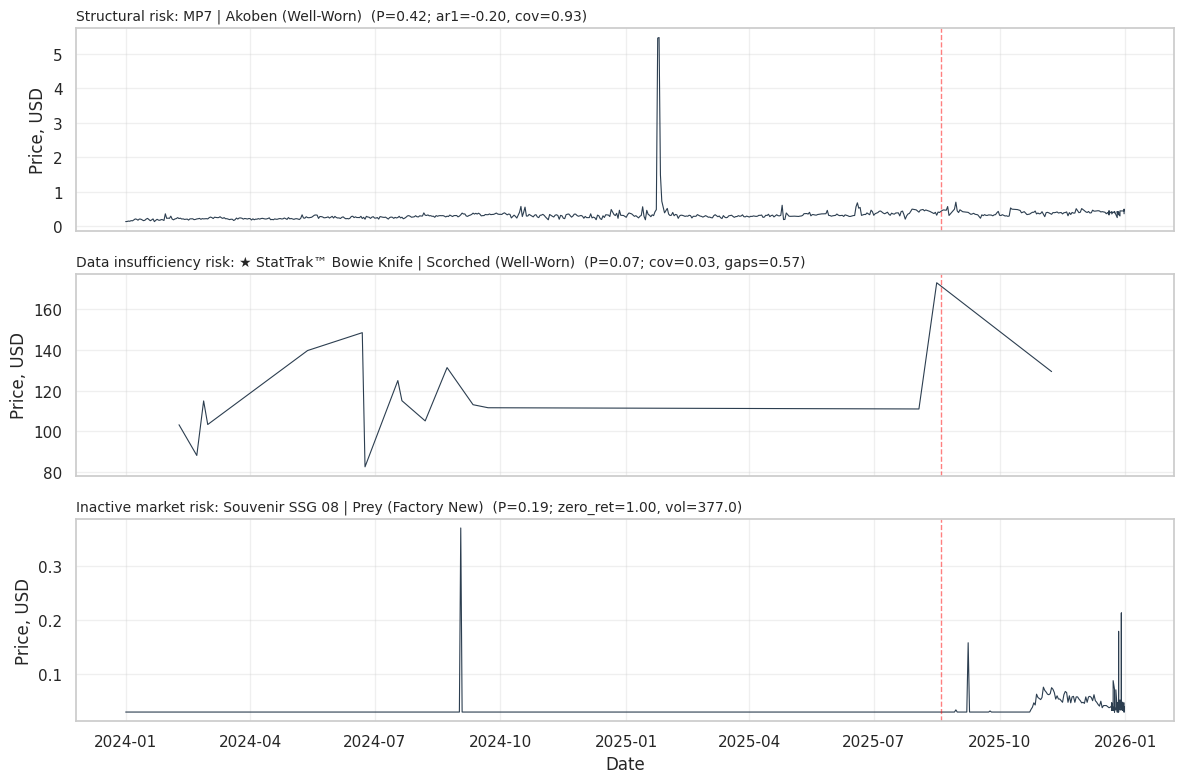

Structural risk: MP7 | Akoben (Well-Worn) | P=0.421 | ar1=-0.20, cov=0.93
Data insufficiency risk: ★ StatTrak™ Bowie Knife | Scorched (Well-Worn) | P=0.074 | cov=0.03, gaps=0.57
Inactive market risk: Souvenir SSG 08 | Prey (Factory New) | P=0.192 | zero_ret=1.00, vol=377.0


In [ ]:
plt.rcParams['font.family'] = 'DejaVu Sans'

gate_df["dt_proba"] = proba_dt
non_forecastable = gate_df[gate_df["dt_proba"] < 0.5].copy()

print(f"Non-forecastable items: {len(non_forecastable)}")
print("\nDistributions:")
print(non_forecastable[DT_FEATURES].describe())

q = non_forecastable[DT_FEATURES].quantile([0.25, 0.5, 0.75])

# Structural risk: торгується регулярно, але хаотично
struct = non_forecastable[
    (non_forecastable["coverage_ratio"] > q.loc[0.5, "coverage_ratio"]) &
    (non_forecastable["ar1"].abs() < non_forecastable["ar1"].abs().quantile(0.5))
].copy()

if len(struct) == 0:
    print("⚠ Structural fallback: brak strict candidates")
    struct = non_forecastable.copy()

structural = struct.reindex(
    struct["ar1"].abs().sort_values().index
).iloc[0]

# Data insufficiency risk: мало даних
data_insuff = non_forecastable[
    non_forecastable["coverage_ratio"] < q.loc[0.25, "coverage_ratio"]
].copy()

if len(data_insuff) == 0:
    data_insuff_row = non_forecastable.sort_values("coverage_ratio").iloc[0]
else:
    data_insuff_row = data_insuff.sort_values(
        "pct_gaps_gt7", ascending=False
    ).iloc[0]

# Inactive market: висока частка zero returns
inactive = non_forecastable[
    non_forecastable["zero_return_frac"] > q.loc[0.75, "zero_return_frac"]
].copy()

if len(inactive) == 0:
    inactive_row = non_forecastable.sort_values(
        "zero_return_frac", ascending=False
    ).iloc[0]
else:
    inactive_row = inactive.sort_values(
        "zero_return_frac", ascending=False
    ).iloc[0]

items_demo = [
    (structural["steam_market_hash_name"], structural["dt_proba"],
     "Structural risk",
     f"ar1={structural['ar1']:.2f}, cov={structural['coverage_ratio']:.2f}"),
    (data_insuff_row["steam_market_hash_name"], data_insuff_row["dt_proba"],
     "Data insufficiency risk",
     f"cov={data_insuff_row['coverage_ratio']:.2f}, gaps={data_insuff_row['pct_gaps_gt7']:.2f}"),
    (inactive_row["steam_market_hash_name"], inactive_row["dt_proba"],
     "Inactive market risk",
     f"zero_ret={inactive_row['zero_return_frac']:.2f}, vol={inactive_row['mean_volume']:.1f}"),
]

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for ax, (name, proba, label, stats) in zip(axes, items_demo):
    d = df[df["steam_market_hash_name"] == name].sort_values("date")
    
    ax.plot(d["date"], d["price"], linewidth=0.8, color="#2C3E50")
    ax.axvline(global_split_date, color="red", linestyle="--",
               alpha=0.5, linewidth=1)
    
    short_name = name[:50] + "..." if len(name) > 50 else name
    ax.set_title(
        f"{label}: {short_name}  (P={proba:.2f}; {stats})",
        loc="left", fontsize=10
    )
    ax.set_ylabel("Price, USD")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.savefig("F:/analysis/plots/fig_risk_types.png", dpi=300)
plt.show()

for name, proba, label, stats in items_demo:
    print(f"{label}: {name} | P={proba:.3f} | {stats}")

## Маленька очистка даних перед формуванням часових ознак

In [18]:
with open("F:/analysis/data/pools.pkl", "wb") as f:
    pickle.dump(pools, f)
with open("F:/analysis/data/global_split_date.pkl", "wb") as f:
    pickle.dump(global_split_date, f)

In [ ]:
vars_to_delete = [
    # Важкі датафрейми
    "df_historical", "features_dt", "gate_df", "train_df", "test_df", 
    "train_enn", "train_renn", "train_drop3", "baseline", "eval_df",
    # Матриці та масиви
    "X_scaled_is", "X_renn", "X_drop3", "y_train", "y_test", "y_renn", "y_drop3", "y_pred",
    "proba", "proba_dt", "proba_enn", "proba_renn", "proba_drop3", "proba_rf_gate",
    "mae_train", "sorted_mae", "distance", "distances", "indices", "cdf", "x_norm",
    "mask_renn", "drop3_mask", "enn_mask", "enemy_dist", "enemy_dists", "preds",
    # Моделі
    "best_dt", "dt_enn", "dt_renn", "dt_drop3", "rf_gate", "knn_is", "knn_r", "nn", "baseline_rf",
    "models_to_eval"
]

for var in vars_to_delete:
    if var in locals():
        del locals()[var]

gc.collect()

# Models Training (Benchmark)

In [ ]:
# ГЕНЕРАЦІЯ ЧАСОВИХ ФІЧ 
df_ts = df.copy()
g = df_ts.groupby("steam_market_hash_name")

df_ts["log_players"] = np.log(df_ts["avg_players"])
df_ts["logret_fwd7"] = g["log_price"].shift(-7) - df_ts["log_price"]
df_ts["target_direction"] = (df_ts["logret_fwd7"] > 0).astype(int)

df_ts["logret_lag_7d"] = g["logret_fwd7"].shift(7)
df_ts["log_price_lag1"] = g["log_price"].shift(1)
df_ts["log_price_ma7"] = g["log_price_lag1"].transform(lambda x: x.rolling(7).mean())
df_ts["log_price_dev_ma7"] = df_ts["log_price_lag1"] - df_ts["log_price_ma7"]
df_ts["log_volume_lag1"] = np.log1p(g["amount"].shift(1))
df_ts["log_players_lag1"] = np.log(g["avg_players"].shift(1))
df_ts["liquidity_lag1"] = g["liquidity"].shift(1) / 100.0

FEATURES_TS = [
    "logret_lag_7d", "log_price_dev_ma7", "log_volume_lag1", 
    "log_players_lag1", "liquidity_lag1", "sale_pressure",       
    "tournament_pressure", "exterior_score", "is_stattrak", 
    "is_souvenir", "skin_age_days", "steam_rarity", 
    "exterior", "weapon", "collection"
]

## 1. Classical Models

### - Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

MODEL_CODE = "lr"
BASE_DIR = f"F:/analysis/models_data/{MODEL_CODE}"
results_lr = []

for sub in ["models", "preps", "probs"]:
    os.makedirs(os.path.join(BASE_DIR, sub), exist_ok=True)

In [ ]:
print(f"СТАРТ ЕКСПЕРИМЕНТУ: {MODEL_CODE.upper()}")

for pool_name, items in pools.items():
    print(f"\n Pool: {pool_name}")
    
    safe_name = re.sub(r'[^a-zA-Z0-9_\-]', '_', pool_name)
    
    d_p = df_ts[df_ts["steam_market_hash_name"].isin(items)].copy()
    d_p = d_p.dropna(subset=["target_direction"] + FEATURES_TS)
    d_p = d_p.sort_values("date").reset_index(drop=True)
    
    if len(d_p) < 1000:
        del d_p; gc.collect()
        continue

    train_p = d_p[d_p["date"] < global_split_date].copy()
    test_p = d_p[d_p["date"] >= (global_split_date + pd.Timedelta(days=7))].copy()
    del d_p; gc.collect()

    cat_features = ["steam_rarity", "exterior", "weapon", "collection"]
    num_features = [f for f in FEATURES_TS if f not in cat_features]
    
    # Масштабування + OneHot
    temp_preprocessor = ColumnTransformer([
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

    X_tr = temp_preprocessor.fit_transform(train_p[FEATURES_TS])
    y_tr = train_p["target_direction"]
    X_te = temp_preprocessor.transform(test_p[FEATURES_TS])
    y_te = test_p["target_direction"]

    model = LogisticRegression(
        max_iter=1000, 
        C=0.1, 
        class_weight="balanced", 
        random_state=42,
        n_jobs=-1
    )
    
    print("Навчання...")
    model.fit(X_tr, y_tr)
    
    joblib.dump(model, f"{BASE_DIR}/models/model_{safe_name}.joblib")
    joblib.dump(temp_preprocessor, f"{BASE_DIR}/preps/prep_{safe_name}.joblib")
    
    print("Оцінка:")
    probs = model.predict_proba(X_te)[:, 1]

    test_bundle = {
        "probs": probs,
        "y_true": y_te.values
    }
    joblib.dump(test_bundle, f"{BASE_DIR}/probs/res_{safe_name}.joblib")

    preds = (probs >= 0.5).astype(int)
    roc_auc = roc_auc_score(y_te, probs)
    precision = precision_score(y_te, preds, zero_division=0)
    accuracy = accuracy_score(y_te, preds)
    
    print(f"Результат: ROC-AUC={roc_auc:.4f}, Precision={precision:.4f}, Accuracy={accuracy:.4f}")
    
    results_lr.append({
        "Пул": pool_name, 
        "ROC-AUC": round(roc_auc, 4), 
        "Precision": round(precision, 4),
        "Accuracy": round(accuracy, 4)
    })
    
    del train_p, test_p, X_tr, X_te, model, temp_preprocessor, test_bundle, probs, preds
    gc.collect()

In [ ]:
print("ФІНАЛЬНІ РЕЗУЛЬТАТИ LOGISTIC REGRESSION")
eval_lr_df = pd.DataFrame(results_lr)
print(eval_lr_df.to_string(index=False))

with open(f"{BASE_DIR}/results_{MODEL_CODE}.pkl", "wb") as f:
    pickle.dump(results_lr, f)

### - SVM

In [34]:
from sklearn.linear_model import SGDClassifier
from sklearn.calibration import CalibratedClassifierCV

MODEL_CODE = "svm"
BASE_DIR = f"F:/analysis/models_data/{MODEL_CODE}"
results_svm = []

for sub in ["models", "preps", "probs"]:
    os.makedirs(os.path.join(BASE_DIR, sub), exist_ok=True)

In [ ]:
total_hist_rows = len(df_ts[df_ts["date"] < global_split_date])
sample_limit = int(total_hist_rows * 0.20) 

print(f"СТАРТ ЕКСПЕРИМЕНТУ: {MODEL_CODE.upper()} (Optimized SGD)")
print(f"Об'єм вибірки: {sample_limit} рядків (20% історії)")

for pool_name, items in pools.items():
    print(f"\nPool: {pool_name}")
    safe_name = re.sub(r'[^a-zA-Z0-9_\-]', '_', pool_name)
    
    d_p = df_ts[df_ts["steam_market_hash_name"].isin(items)].copy()
    d_p = d_p.dropna(subset=["target_direction"] + FEATURES_TS)
    d_p = d_p.sort_values("date").reset_index(drop=True)
    
    if len(d_p) < 1000:
        del d_p; gc.collect()
        continue

    train_p = d_p[d_p["date"] < global_split_date].copy()
    test_p = d_p[d_p["date"] >= (global_split_date + pd.Timedelta(days=7))].copy()
    del d_p; gc.collect()

    if len(train_p) > sample_limit:
        train_p = train_p.tail(sample_limit)

    cat_features = ["steam_rarity", "exterior", "weapon", "collection"]
    num_features = [f for f in FEATURES_TS if f not in cat_features]
    
    temp_preprocessor = ColumnTransformer([
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

    X_tr = temp_preprocessor.fit_transform(train_p[FEATURES_TS])
    y_tr = train_p["target_direction"]
    X_te = temp_preprocessor.transform(test_p[FEATURES_TS])
    y_te = test_p["target_direction"]

    base_model = SGDClassifier(loss='hinge', penalty='l2', alpha=0.0001, random_state=42)
    model = CalibratedClassifierCV(base_model, cv=3, n_jobs=-1) 
    
    print(f"Навчання (Parallel Folds) на {X_tr.shape[0]} рядках...")
    model.fit(X_tr, y_tr)
    
    joblib.dump(model, f"{BASE_DIR}/models/model_{safe_name}.joblib")
    joblib.dump(temp_preprocessor, f"{BASE_DIR}/preps/prep_{safe_name}.joblib")
    
    print("Оцінка...")
    probs = model.predict_proba(X_te)[:, 1]
    test_bundle = {"probs": probs, "y_true": y_te.values}
    joblib.dump(test_bundle, f"{BASE_DIR}/probs/res_{safe_name}.joblib")

    preds = (probs >= 0.5).astype(int)
    roc_auc = roc_auc_score(y_te, probs)
    precision = precision_score(y_te, preds, zero_division=0)
    accuracy = accuracy_score(y_te, preds)
    
    print(f"Результат: ROC-AUC={roc_auc:.4f}, Precision={precision:.4f}, Accuracy={accuracy:.4f}")
    
    results_svm.append({
        "Пул": pool_name, 
        "ROC-AUC": round(roc_auc, 4), 
        "Precision": round(precision, 4),
        "Accuracy": round(accuracy, 4)
    })
    
    del train_p, test_p, X_tr, X_te, model, temp_preprocessor, test_bundle, probs, preds
    gc.collect()

In [ ]:
print(f"ФІНАЛЬНІ РЕЗУЛЬТАТИ ЕКСПЕРИМЕНТУ: {MODEL_CODE.upper()}")

eval_svm_df = pd.DataFrame(results_svm)
print(eval_svm_df.to_string(index=False))

with open(f"{BASE_DIR}/results_{MODEL_CODE}.pkl", "wb") as f:
    pickle.dump(results_svm, f)

### - KNN, Naive Bayes

In [37]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

MODELS = {
    "knn": {"code": "knn", "results": []},
    "nb": {"code": "nb", "results": []}
}

for m_key in MODELS:
    m_info = MODELS[m_key]
    m_info["dir"] = f"F:/analysis/models_data/{m_info['code']}"
    for sub in ["models", "preps", "probs"]:
        os.makedirs(os.path.join(m_info["dir"], sub), exist_ok=True)

In [ ]:
print("СТАРТ ЕКСПЕРИМЕНТУ: KNN & Naive Bayes")

cat_features = ["steam_rarity", "exterior", "weapon", "collection"]
num_features = [f for f in FEATURES_TS if f not in cat_features]

for pool_name, items in pools.items():
    print(f"\nPool: {pool_name}")
    safe_name = re.sub(r'[^a-zA-Z0-9_\-]', '_', pool_name)
    
    d_p = df_ts[df_ts["steam_market_hash_name"].isin(items)].copy()
    d_p = d_p.dropna(subset=["target_direction"] + FEATURES_TS)
    d_p = d_p.sort_values("date").reset_index(drop=True)
    
    if len(d_p) < 1000:
        print(f"   Замало даних ({len(d_p)}). Пропускаємо.")
        del d_p; gc.collect()
        continue

    train_p = d_p[d_p["date"] < global_split_date].copy()
    test_p = d_p[d_p["date"] >= (global_split_date + pd.Timedelta(days=7))].copy()
    del d_p; gc.collect()

    scaler = StandardScaler()
    X_tr_all = scaler.fit_transform(train_p[num_features])
    X_te = scaler.transform(test_p[num_features])
    y_tr_all = train_p["target_direction"].values
    y_te = test_p["target_direction"].values

    knn_limit = 30000
    X_tr_knn = X_tr_all[-knn_limit:] if len(X_tr_all) > knn_limit else X_tr_all
    y_tr_knn = y_tr_all[-knn_limit:] if len(y_tr_all) > knn_limit else y_tr_all

    print(f"   Навчання KNN (k=15, Parallel)...")
    knn_model = KNeighborsClassifier(n_neighbors=15, algorithm='auto', n_jobs=-1)
    knn_model.fit(X_tr_knn, y_tr_knn)
    
    probs_knn = knn_model.predict_proba(X_te)[:, 1]
    
    joblib.dump(knn_model, f"{MODELS['knn']['dir']}/models/model_{safe_name}.joblib")
    joblib.dump(scaler, f"{MODELS['knn']['dir']}/preps/prep_{safe_name}.joblib")
    joblib.dump({"probs": probs_knn, "y_true": y_te}, f"{MODELS['knn']['dir']}/probs/res_{safe_name}.joblib")
    
    roc_knn = roc_auc_score(y_te, probs_knn)
    prec_knn = precision_score(y_te, (probs_knn >= 0.5).astype(int), zero_division=0)
    acc_knn = accuracy_score(y_te, (probs_knn >= 0.5).astype(int))
    
    print(f"   KNN Результат: ROC-AUC={roc_knn:.4f}, Precision={prec_knn:.4f}, Accuracy={acc_knn:.4f}")
    MODELS["knn"]["results"].append({"Пул": pool_name, "ROC-AUC": round(roc_knn, 4), "Precision": round(prec_knn, 4), "Accuracy": round(acc_knn, 4)})

    print(f"   Навчання Naive Bayes...")
    nb_model = GaussianNB()
    nb_model.fit(X_tr_all, y_tr_all)
    
    probs_nb = nb_model.predict_proba(X_te)[:, 1]
    
    joblib.dump(nb_model, f"{MODELS['nb']['dir']}/models/model_{safe_name}.joblib")
    joblib.dump(scaler, f"{MODELS['nb']['dir']}/preps/prep_{safe_name}.joblib")
    joblib.dump({"probs": probs_nb, "y_true": y_te}, f"{MODELS['nb']['dir']}/probs/res_{safe_name}.joblib")
    
    roc_nb = roc_auc_score(y_te, probs_nb)
    prec_nb = precision_score(y_te, (probs_nb >= 0.5).astype(int), zero_division=0)
    acc_nb = accuracy_score(y_te, (probs_nb >= 0.5).astype(int))
    
    print(f"   NB Результат:  ROC-AUC={roc_nb:.4f}, Precision={prec_nb:.4f}, Accuracy={acc_nb:.4f}")
    MODELS["nb"]["results"].append({"Пул": pool_name, "ROC-AUC": round(roc_nb, 4), "Precision": round(prec_nb, 4), "Accuracy": round(acc_nb, 4)})

    del train_p, test_p, X_tr_all, X_te, knn_model, nb_model, probs_knn, probs_nb
    gc.collect()


In [ ]:
for m_key in MODELS:
    m = MODELS[m_key]
    print(f"\nФІНАЛЬНІ РЕЗУЛЬТАТИ: {m['code'].upper()}")
    df_res = pd.DataFrame(m["results"])
    print(df_res.to_string(index=False))
    with open(f"{m['dir']}/results_{m['code']}.pkl", "wb") as f:
        pickle.dump(m["results"], f)

## 2. Econometrics Models

### - ARIMA

In [22]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

MODEL_CODE = "arima"
BASE_DIR = f"F:/analysis/models_data/{MODEL_CODE}"
results_arima = []
H_DAYS = 7

for sub in ["models", "preps", "probs"]:
    os.makedirs(os.path.join(BASE_DIR, sub), exist_ok=True)

In [ ]:
print(f"СТАРТ ЕКСПЕРИМЕНТУ: {MODEL_CODE.upper()} (StatsForecast)")

for pool_name, items in pools.items():
    print(f"\nPool: {pool_name}")
    safe_name = re.sub(r'[^a-zA-Z0-9_\-]', '_', pool_name)
    
    d_p = df_ts[df_ts["steam_market_hash_name"].isin(items)].copy()
    d_p = d_p.dropna(subset=["target_direction"] + FEATURES_TS)
    
    d_p = d_p.rename(columns={
        'steam_market_hash_name': 'unique_id',
        'date': 'ds',
        'log_price': 'y'
    })
    d_p = d_p.sort_values(['unique_id', 'ds']).reset_index(drop=True)

    train_df = d_p[d_p['ds'] < global_split_date].copy()
    test_df = d_p[d_p['ds'] >= global_split_date].copy()
    
    if len(train_df) < 1000:
        print(f"   Замало даних ({len(train_df)}). Пропускаємо.")
        del d_p, train_df, test_df; gc.collect()
        continue

    model = AutoARIMA(season_length=7)
    sf = StatsForecast(models=[model], freq='D', n_jobs=-1)

    print(f"   Навчання та прогноз на {H_DAYS} днів...")
    forecast_df = sf.forecast(df=train_df[['unique_id', 'ds', 'y']], h=H_DAYS)
    
    joblib.dump(sf, f"{BASE_DIR}/models/model_{safe_name}.joblib")

    last_train_y = train_df.groupby('unique_id').tail(1).set_index('unique_id')['y']
    forecast_df = forecast_df.sort_values(['unique_id', 'ds'])
    
    forecast_df['prev_y'] = forecast_df.groupby('unique_id')['AutoARIMA'].shift(1)
    forecast_df['prev_y'] = forecast_df['prev_y'].fillna(forecast_df['unique_id'].map(last_train_y))
    
    forecast_df['pred_diff'] = forecast_df['AutoARIMA'] - forecast_df['prev_y']
    forecast_df['pred_class'] = (forecast_df['pred_diff'] > 0).astype(int)

    merged = pd.merge(
        test_df[['unique_id', 'ds', 'target_direction']], 
        forecast_df[['unique_id', 'ds', 'pred_diff', 'pred_class']], 
        on=['unique_id', 'ds'], 
        how='inner'
    )

    if len(merged) == 0:
        print("   Помилка: Немає спільних дат для оцінки.")
        del d_p, train_df, test_df, sf, forecast_df, merged; gc.collect()
        continue

    y_true = merged['target_direction'].values.astype(int)
    y_scores = merged['pred_diff'].values
    y_pred = merged['pred_class'].values

    test_bundle = {
        "probs": y_scores,
        "y_true": y_true
    }
    joblib.dump(test_bundle, f"{BASE_DIR}/probs/res_{safe_name}.joblib")

    roc_auc = roc_auc_score(y_true, y_scores)
    precision = precision_score(y_true, y_pred, zero_division=0)
    accuracy = accuracy_score(y_true, y_pred)

    print(f"   Результат: ROC-AUC={roc_auc:.4f}, Precision={precision:.4f}, Accuracy={accuracy:.4f}")
    
    results_arima.append({
        "Пул": pool_name, 
        "ROC-AUC": round(roc_auc, 4), 
        "Precision": round(precision, 4),
        "Accuracy": round(accuracy, 4)
    })
    
    del d_p, train_df, test_df, sf, forecast_df, merged, test_bundle, y_true, y_scores, y_pred
    gc.collect()

In [ ]:
for pool_name in pools.keys():
    safe_name = re.sub(r'[^a-zA-Z0-9_\-]', '_', pool_name)
    prep_path = f"{BASE_DIR}/preps/prep_{safe_name}.joblib"
    if not os.path.exists(prep_path):
        joblib.dump("No_preprocessor_for_ARIMA", prep_path)

print(f"ФІНАЛЬНІ РЕЗУЛЬТАТИ: {MODEL_CODE.upper()}")
eval_arima_df = pd.DataFrame(results_arima)
print(eval_arima_df.to_string(index=False))

with open(f"{BASE_DIR}/results_{MODEL_CODE}.pkl", "wb") as f:
    pickle.dump(results_arima, f)

## 3.1 Tree-based Models

### - DecisionTreeClassifier

In [21]:
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

MODEL_CODE = "dt"
BASE_DIR = f"F:/analysis/models_data/{MODEL_CODE}"
results_dt = []

for sub in ["models", "preps", "probs"]:
    os.makedirs(os.path.join(BASE_DIR, sub), exist_ok=True)

In [ ]:
print(f"СТАРТ ЕКСПЕРИМЕНТУ: {MODEL_CODE.upper()} (Simple Decision Tree)")

for pool_name, items in pools.items():
    print(f"\nPool: {pool_name}")
    safe_name = re.sub(r'[^a-zA-Z0-9_\-]', '_', pool_name)
    
    d_p = df_ts[df_ts["steam_market_hash_name"].isin(items)].copy()
    d_p = d_p.dropna(subset=["target_direction"] + FEATURES_TS)
    d_p = d_p.sort_values("date").reset_index(drop=True)
    
    if len(d_p) < 1000:
        print(f"   Замало даних ({len(d_p)}). Пропускаємо.")
        del d_p; gc.collect()
        continue

    train_p = d_p[d_p["date"] < global_split_date].copy()
    test_p = d_p[d_p["date"] >= global_split_date + pd.Timedelta(days=7)].copy()
    del d_p; gc.collect()

    cat_features = ["steam_rarity", "exterior", "weapon", "collection"]
    num_features = [f for f in FEATURES_TS if f not in cat_features]
    
    temp_preprocessor = ColumnTransformer([
        ('num', 'passthrough', num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True, dtype=np.float32), cat_features)
    ])

    X_tr = temp_preprocessor.fit_transform(train_p[FEATURES_TS])
    y_tr = train_p["target_direction"]
    X_te = temp_preprocessor.transform(test_p[FEATURES_TS])
    y_te = test_p["target_direction"]

    model = DecisionTreeClassifier(
        max_depth=10, 
        min_samples_leaf=100, 
        class_weight="balanced", 
        random_state=42
    )
    
    print("   Навчання...")
    model.fit(X_tr, y_tr)
    
    joblib.dump(model, f"{BASE_DIR}/models/model_{safe_name}.joblib")
    joblib.dump(temp_preprocessor, f"{BASE_DIR}/preps/prep_{safe_name}.joblib")
    
    print("   Оцінка...")
    probs = model.predict_proba(X_te)[:, 1]
    
    test_bundle = {
        "probs": probs,
        "y_true": y_te.values
    }
    joblib.dump(test_bundle, f"{BASE_DIR}/probs/res_{safe_name}.joblib")

    preds = (probs >= 0.5).astype(int)
    roc_auc = roc_auc_score(y_te, probs)
    precision = precision_score(y_te, preds, zero_division=0)
    accuracy = accuracy_score(y_te, preds)
    
    print(f"   Результат: ROC-AUC={roc_auc:.4f}, Precision={precision:.4f}, Accuracy={accuracy:.4f}")
    
    results_dt.append({
        "Пул": pool_name, 
        "ROC-AUC": round(roc_auc, 4), 
        "Precision": round(precision, 4),
        "Accuracy": round(accuracy, 4)
    })
    
    del train_p, test_p, X_tr, X_te, model, temp_preprocessor, test_bundle, probs, preds
    gc.collect()

In [ ]:
print(f"ФІНАЛЬНІ РЕЗУЛЬТАТИ: {MODEL_CODE.upper()}")
eval_dt_df = pd.DataFrame(results_dt)
print(eval_dt_df.to_string(index=False))

with open(f"{BASE_DIR}/results_{MODEL_CODE}.pkl", "wb") as f:
    pickle.dump(results_dt, f)

### - RandomForestClassifier

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer

MODEL_CODE = "rf"
BASE_DIR = f"F:/analysis/models_data/{MODEL_CODE}"
results_rf = []

for sub in ["models", "preps", "probs"]:
    os.makedirs(os.path.join(BASE_DIR, sub), exist_ok=True)

In [ ]:
print(f"СТАРТ ЕКСПЕРИМЕНТУ: {MODEL_CODE.upper()} (Random Forest)")

for pool_name, items in pools.items():
    print(f"\nPool: {pool_name} (Скінів: {len(items)})")
    safe_name = re.sub(r'[^a-zA-Z0-9_\-]', '_', pool_name)
    
    d_p = df_ts[df_ts["steam_market_hash_name"].isin(items)].copy()
    d_p = d_p.dropna(subset=["target_direction"] + FEATURES_TS)
    d_p = d_p.sort_values("date").reset_index(drop=True)
    
    if len(d_p) < 1000:
        print(f"   Замало даних ({len(d_p)}). Пропускаємо.")
        del d_p; gc.collect()
        continue

    train_p = d_p[d_p["date"] < global_split_date].copy()
    test_p = d_p[d_p["date"] >= global_split_date + pd.Timedelta(days=7)].copy()
    del d_p; gc.collect()

    cat_features = ["steam_rarity", "exterior", "weapon", "collection"]
    num_features = [f for f in FEATURES_TS if f not in cat_features]
    
    temp_preprocessor = ColumnTransformer([
        ('num', 'passthrough', num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True, dtype=np.float32), cat_features)
    ])

    X_tr = temp_preprocessor.fit_transform(train_p[FEATURES_TS])
    y_tr = train_p["target_direction"]
    X_te = temp_preprocessor.transform(test_p[FEATURES_TS])
    y_te = test_p["target_direction"]

    model = RandomForestClassifier(
        n_estimators=200, 
        max_depth=12, 
        min_samples_leaf=50, 
        class_weight="balanced", 
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    
    print("   Навчання...")
    model.fit(X_tr, y_tr)
    
    joblib.dump(model, f"{BASE_DIR}/models/model_{safe_name}.joblib")
    joblib.dump(temp_preprocessor, f"{BASE_DIR}/preps/prep_{safe_name}.joblib")
    
    print("   Оцінка...")
    probs = model.predict_proba(X_te)[:, 1]
    
    test_bundle = {
        "probs": probs,
        "y_true": y_te.values
    }
    joblib.dump(test_bundle, f"{BASE_DIR}/probs/res_{safe_name}.joblib")

    preds = (probs >= 0.5).astype(int)
    roc_auc = roc_auc_score(y_te, probs)
    precision = precision_score(y_te, preds, zero_division=0)
    accuracy = accuracy_score(y_te, preds)
    
    print(f"   Результат: ROC-AUC={roc_auc:.4f}, Precision={precision:.4f}, Accuracy={accuracy:.4f}")
    
    results_rf.append({
        "Пул": pool_name, 
        "ROC-AUC": round(roc_auc, 4), 
        "Precision": round(precision, 4),
        "Accuracy": round(accuracy, 4)
    })
    
    del train_p, test_p, X_tr, X_te, model, temp_preprocessor, test_bundle, probs, preds
    gc.collect()

In [ ]:
print(f"ФІНАЛЬНІ РЕЗУЛЬТАТИ: {MODEL_CODE.upper()}")
eval_rf_df = pd.DataFrame(results_rf)
print(eval_rf_df.to_string(index=False))

with open(f"{BASE_DIR}/results_{MODEL_CODE}.pkl", "wb") as f:
    pickle.dump(results_rf, f)

## 3.2 Gradient Boosting

In [ ]:
import tensorflow as tf

### - CatBoost

In [28]:
from catboost import CatBoostClassifier

MODEL_CODE = "cb"
BASE_DIR = f"F:/analysis/models_data/{MODEL_CODE}"
results_cb = []

for sub in ["models", "preps", "probs"]:
    os.makedirs(os.path.join(BASE_DIR, sub), exist_ok=True)

In [ ]:
print(f"СТАРТ ЕКСПЕРИМЕНТУ: {MODEL_CODE.upper()} (CatBoost)")

cat_features = ["steam_rarity", "exterior", "weapon", "collection"]

for pool_name, items in pools.items():
    print(f"\nPool: {pool_name} (Скінів: {len(items)})")
    safe_name = re.sub(r'[^a-zA-Z0-9_\-]', '_', pool_name)
    
    d_p = df_ts[df_ts["steam_market_hash_name"].isin(items)].copy()
    d_p = d_p.dropna(subset=["target_direction"] + FEATURES_TS)
    d_p = d_p.sort_values("date").reset_index(drop=True)
    
    if len(d_p) < 1000:
        print("   Замало даних. Пропускаємо.")
        del d_p; gc.collect()
        continue

    train_p = d_p[d_p["date"] < global_split_date].copy()
    test_p = d_p[d_p["date"] >= global_split_date + pd.Timedelta(days=7)].copy()
    del d_p; gc.collect()

    X_train_full = train_p[FEATURES_TS].copy()
    y_train_full = train_p["target_direction"]
    X_test = test_p[FEATURES_TS].copy()
    y_test = test_p["target_direction"]

    for col in cat_features:
        X_train_full[col] = X_train_full[col].astype(str)
        X_test[col] = X_test[col].astype(str)

    sorted_dates = np.sort(train_p["date"].values)
    val_date_threshold = sorted_dates[int(len(sorted_dates) * 0.9)]

    tr_mask = train_p["date"] < val_date_threshold
    val_mask = train_p["date"] >= val_date_threshold

    X_tr = X_train_full[tr_mask].copy()
    y_tr = y_train_full[tr_mask]
    
    X_val = X_train_full[val_mask].copy()
    y_val = y_train_full[val_mask]

    print(f"   Train рядків: {len(X_tr)} | Val рядків: {len(X_val)} | Test рядків: {len(X_test)}")

    if 'tf' in globals():
        tf.keras.backend.clear_session()
        
    model = CatBoostClassifier(
        iterations=1000, 
        learning_rate=0.03, 
        depth=5,
        cat_features=cat_features,
        task_type="CPU", 
        random_seed=42, 
        eval_metric="AUC",
        verbose=0
    )
    
    print("   Навчання...")
    model.fit(
        X_tr, y_tr, 
        eval_set=(X_val, y_val), 
        early_stopping_rounds=50
    )
    
    joblib.dump(model, f"{BASE_DIR}/models/model_{safe_name}.joblib")
    joblib.dump("CatBoost_Internal_Prep", f"{BASE_DIR}/preps/prep_{safe_name}.joblib")
    
    print("   Оцінка...")
    probs = model.predict_proba(X_test)[:, 1]
    
    test_bundle = {
        "probs": probs,
        "y_true": y_test.values
    }
    joblib.dump(test_bundle, f"{BASE_DIR}/probs/res_{safe_name}.joblib")

    preds = (probs >= 0.5).astype(int)
    
    roc_auc = roc_auc_score(y_test, probs)
    precision = precision_score(y_test, preds, zero_division=0)
    accuracy = accuracy_score(y_test, preds)
    
    print(f"   Результат: ROC-AUC={roc_auc:.4f}, Precision={precision:.4f}, Accuracy={accuracy:.4f}")
    
    results_cb.append({
        "Пул": pool_name, 
        "ROC-AUC": round(roc_auc, 4), 
        "Precision": round(precision, 4),
        "Accuracy": round(accuracy, 4)
    })
    
    del train_p, test_p, X_train_full, X_test, X_tr, X_val, model, test_bundle, probs, preds
    gc.collect()

In [ ]:
print(f"ФІНАЛЬНІ РЕЗУЛЬТАТИ: {MODEL_CODE.upper()}")
eval_cb_df = pd.DataFrame(results_cb)
print(eval_cb_df.to_string(index=False))

with open(f"{BASE_DIR}/results_{MODEL_CODE}.pkl", "wb") as f:
    pickle.dump(results_cb, f)

### - XGBoost

In [31]:
import xgboost as xgb

MODEL_CODE = "xgb"
BASE_DIR = f"F:/analysis/models_data/{MODEL_CODE}"
results_xgb = []
cat_features = ["steam_rarity", "exterior", "weapon", "collection"]

for sub in ["models", "preps", "probs"]:
    os.makedirs(os.path.join(BASE_DIR, sub), exist_ok=True)

In [ ]:
print(f"СТАРТ ЕКСПЕРИМЕНТУ: {MODEL_CODE.upper()} (XGBoost)")

for pool_name, items in pools.items():
    print(f"\nPool: {pool_name} (Скінів: {len(items)})")
    
    safe_name = re.sub(r'[^a-zA-Z0-9_\-]', '_', pool_name)
    
    d_p = df_ts[df_ts["steam_market_hash_name"].isin(items)].copy()
    d_p = d_p.dropna(subset=["target_direction"] + FEATURES_TS)
    d_p = d_p.sort_values("date").reset_index(drop=True)
    
    if len(d_p) < 1000:
        print("   Замало даних. Пропускаємо.")
        del d_p; gc.collect()
        continue

    train_p = d_p[d_p["date"] < global_split_date].copy()
    test_p = d_p[d_p["date"] >= global_split_date + pd.Timedelta(days=7)].copy()
    del d_p; gc.collect()

    X_train_full = train_p[FEATURES_TS].copy()
    y_train_full = train_p["target_direction"]
    X_test = test_p[FEATURES_TS].copy()
    y_test = test_p["target_direction"]

    for col in cat_features:
        X_train_full[col] = X_train_full[col].astype("category")
        X_test[col] = X_test[col].astype("category")

    sorted_dates = np.sort(train_p["date"].values)
    val_date_threshold = sorted_dates[int(len(sorted_dates) * 0.9)]

    tr_mask = train_p["date"] < val_date_threshold
    val_mask = train_p["date"] >= val_date_threshold

    X_tr = X_train_full[tr_mask].copy()
    y_tr = y_train_full[tr_mask]
    X_val = X_train_full[val_mask].copy()
    y_val = y_train_full[val_mask]

    print(f"   Train рядків: {len(X_tr)} | Val рядків: {len(X_val)} | Test рядків: {len(X_test)}")

    model = xgb.XGBClassifier(
        n_estimators=1000,
        max_depth=5,
        learning_rate=0.03,
        tree_method="hist",
        device="cpu",
        enable_categorical=True,
        eval_metric="auc",
        early_stopping_rounds=50,
        random_state=42,
        n_jobs=-1
    )
    
    print("   Навчання...")
    model.fit(
        X_tr, y_tr, 
        eval_set=[(X_val, y_val)], 
        verbose=False
    )
    
    joblib.dump(model, f"{BASE_DIR}/models/model_{safe_name}.joblib")
    joblib.dump("XGBoost_Internal_Prep", f"{BASE_DIR}/preps/prep_{safe_name}.joblib")
    
    print("   Оцінка...")
    probs = model.predict_proba(X_test)[:, 1]
    
    test_bundle = {
        "probs": probs,
        "y_true": y_test.values
    }
    joblib.dump(test_bundle, f"{BASE_DIR}/probs/res_{safe_name}.joblib")

    preds = (probs >= 0.5).astype(int)
    
    roc_auc = roc_auc_score(y_test, probs)
    precision = precision_score(y_test, preds, zero_division=0)
    accuracy = accuracy_score(y_test, preds)
    
    print(f"   Результат: ROC-AUC={roc_auc:.4f}, Precision={precision:.4f}, Accuracy={accuracy:.4f}")
    
    results_xgb.append({
        "Пул": pool_name, 
        "ROC-AUC": round(roc_auc, 4), 
        "Precision": round(precision, 4),
        "Accuracy": round(accuracy, 4)
    })
    
    del train_p, test_p, X_train_full, X_test, X_tr, X_val, model, test_bundle, probs, preds
    gc.collect()

In [ ]:
print(f"ФІНАЛЬНІ РЕЗУЛЬТАТИ: {MODEL_CODE.upper()}")
eval_xgb_df = pd.DataFrame(results_xgb)
print(eval_xgb_df.to_string(index=False))

with open(f"{BASE_DIR}/results_{MODEL_CODE}.pkl", "wb") as f:
    pickle.dump(results_xgb, f)

### - LightGBM

In [34]:
import lightgbm as lgb

MODEL_CODE = "lgb"
BASE_DIR = f"F:/analysis/models_data/{MODEL_CODE}"
results_lgb = []
cat_features = ["steam_rarity", "exterior", "weapon", "collection"]

for sub in ["models", "preps", "probs"]:
    os.makedirs(os.path.join(BASE_DIR, sub), exist_ok=True)

In [ ]:
print(f"СТАРТ ЕКСПЕРИМЕНТУ: {MODEL_CODE.upper()} (LightGBM)")

for pool_name, items in pools.items():
    print(f"\nPool: {pool_name} (Скінів: {len(items)})")
    safe_name = re.sub(r'[^a-zA-Z0-9_\-]', '_', pool_name)
    
    d_p = df_ts[df_ts["steam_market_hash_name"].isin(items)].copy()
    d_p = d_p.dropna(subset=["target_direction"] + FEATURES_TS)
    d_p = d_p.sort_values("date").reset_index(drop=True)
    
    if len(d_p) < 1000:
        print("   Замало даних. Пропускаємо.")
        del d_p; gc.collect()
        continue

    train_p = d_p[d_p["date"] < global_split_date].copy()
    test_p = d_p[d_p["date"] >= global_split_date + pd.Timedelta(days=7)].copy()
    del d_p; gc.collect()

    X_train_full = train_p[FEATURES_TS].copy()
    y_train_full = train_p["target_direction"]
    X_test = test_p[FEATURES_TS].copy()
    y_test = test_p["target_direction"]

    for col in cat_features:
        X_train_full[col] = X_train_full[col].astype('category')
        X_test[col] = X_test[col].astype('category')

    sorted_dates = np.sort(train_p["date"].values)
    val_date_threshold = sorted_dates[int(len(sorted_dates) * 0.9)]

    tr_mask = train_p["date"] < val_date_threshold
    val_mask = train_p["date"] >= val_date_threshold

    X_tr = X_train_full[tr_mask].copy()
    y_tr = y_train_full[tr_mask]
    X_val = X_train_full[val_mask].copy()
    y_val = y_train_full[val_mask]

    print(f"   Train рядків: {len(X_tr)} | Val рядків: {len(X_val)} | Test рядків: {len(X_test)}")

    model = lgb.LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        boosting_type='gbdt',
        objective='binary',
        metric='auc',
        random_state=42,
        n_jobs=-1,
        importance_type='gain',
        verbose=-1
    )
    
    print("   Навчання...")
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=0)]
    )
    
    joblib.dump(model, f"{BASE_DIR}/models/model_{safe_name}.joblib")
    joblib.dump("LightGBM_Internal_Prep", f"{BASE_DIR}/preps/prep_{safe_name}.joblib")
    
    print("   Оцінка...")
    probs = model.predict_proba(X_test)[:, 1]
    
    test_bundle = {
        "probs": probs,
        "y_true": y_test.values
    }
    joblib.dump(test_bundle, f"{BASE_DIR}/probs/res_{safe_name}.joblib")

    preds = (probs >= 0.5).astype(int)
    
    roc_auc = roc_auc_score(y_test, probs)
    precision = precision_score(y_test, preds, zero_division=0)
    accuracy = accuracy_score(y_test, preds)
    
    print(f"   Результат: ROC-AUC={roc_auc:.4f}, Precision={precision:.4f}, Accuracy={accuracy:.4f}")
    
    results_lgb.append({
        "Пул": pool_name, 
        "ROC-AUC": round(roc_auc, 4), 
        "Precision": round(precision, 4),
        "Accuracy": round(accuracy, 4)
    })
    
    del train_p, test_p, X_train_full, X_test, X_tr, X_val, model, test_bundle, probs, preds
    gc.collect()

In [ ]:
print(f"ФІНАЛЬНІ РЕЗУЛЬТАТИ: {MODEL_CODE.upper()}")
eval_lgb_df = pd.DataFrame(results_lgb)
print(eval_lgb_df.to_string(index=False))

with open(f"{BASE_DIR}/results_{MODEL_CODE}.pkl", "wb") as f:
    pickle.dump(results_lgb, f)

## 4. Deep Learning

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler, OneHotEncoder

### - MLP

In [23]:
MODEL_CODE = "mlp"
BASE_DIR = f"F:/analysis/models_data/{MODEL_CODE}"
results_mlp = []

cat_features = ["steam_rarity", "exterior", "weapon", "collection"]
num_features = [f for f in FEATURES_TS if f not in cat_features]

for sub in ["models", "preps", "probs"]:
    os.makedirs(os.path.join(BASE_DIR, sub), exist_ok=True)

In [ ]:
print(f"СТАРТ ЕКСПЕРИМЕНТУ: {MODEL_CODE.upper()} (Dense Neural Network)")

for pool_name, items in pools.items():
    print(f"\nPool: {pool_name} (Скінів: {len(items)})")
    safe_name = re.sub(r'[^a-zA-Z0-9_\-]', '_', pool_name)
    
    d_p = df_ts[df_ts["steam_market_hash_name"].isin(items)].copy()
    d_p = d_p.dropna(subset=["target_direction"] + FEATURES_TS)
    d_p = d_p.sort_values("date").reset_index(drop=True)
    
    if len(d_p) < 1000:
        print("   Замало даних. Пропускаємо.")
        del d_p; gc.collect()
        continue

    train_p = d_p[d_p["date"] < global_split_date].copy().reset_index(drop=True)
    test_p = d_p[d_p["date"] >= (global_split_date + pd.Timedelta(days=7))].copy().reset_index(drop=True)
    del d_p; gc.collect()

    train_dates = train_p["date"].values

    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=np.float32), cat_features)
    ])

    print("   Масштабування...")
    X_train_full = preprocessor.fit_transform(train_p[FEATURES_TS]).astype(np.float32)
    y_train_full = train_p["target_direction"].values

    X_test = preprocessor.transform(test_p[FEATURES_TS]).astype(np.float32)
    y_test = test_p["target_direction"].values

    del train_p, test_p; gc.collect()

    # Хронологічна валідація (останні 10% часу трейну)
    sorted_dates = np.sort(train_dates)
    val_date_threshold = sorted_dates[int(len(sorted_dates) * 0.9)]

    tr_mask = train_dates < val_date_threshold
    val_mask = train_dates >= val_date_threshold
    del train_dates; gc.collect()

    X_tr = X_train_full[tr_mask]
    y_tr = y_train_full[tr_mask]

    X_val = X_train_full[val_mask]
    y_val = y_train_full[val_mask]

    del X_train_full, y_train_full, tr_mask, val_mask; gc.collect()

    print(f"   Train рядків: {len(X_tr)} | Val рядків: {len(X_val)} | Test рядків: {len(X_test)}")

    tf.keras.backend.clear_session()
    
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_tr.shape[1],)),
        BatchNormalization(),
        Dropout(0.3),
        
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
        loss='binary_crossentropy', 
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )
    
    print("   Навчання...")
    model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=20,
        batch_size=512,
        callbacks=[EarlyStopping(monitor='val_auc', mode='max', patience=4, restore_best_weights=True)],
        verbose=0
    )
    
    model.save(f"{BASE_DIR}/models/model_{safe_name}.keras")
    joblib.dump(preprocessor, f"{BASE_DIR}/preps/prep_{safe_name}.joblib")
    
    print("   Оцінка...")
    probs = model.predict(X_test, batch_size=1024, verbose=0).flatten()
    
    test_bundle = {
        "probs": probs,
        "y_true": y_test
    }
    joblib.dump(test_bundle, f"{BASE_DIR}/probs/res_{safe_name}.joblib")

    preds = (probs >= 0.5).astype(int)
    
    roc_auc = roc_auc_score(y_test, probs)
    precision = precision_score(y_test, preds, zero_division=0)
    accuracy = accuracy_score(y_test, preds)
    
    print(f"   Результат: ROC-AUC={roc_auc:.4f}, Precision={precision:.4f}, Accuracy={accuracy:.4f}")
    
    results_mlp.append({
        "Пул": pool_name, 
        "ROC-AUC": round(roc_auc, 4), 
        "Precision": round(precision, 4),
        "Accuracy": round(accuracy, 4)
    })
    
    del X_tr, y_tr, X_val, y_val, X_test, y_test, model, preprocessor, test_bundle, probs, preds
    gc.collect()

In [ ]:
print(f"ФІНАЛЬНІ РЕЗУЛЬТАТИ: {MODEL_CODE.upper()}")
eval_mlp_df = pd.DataFrame(results_mlp)
print(eval_mlp_df.to_string(index=False))

with open(f"{BASE_DIR}/results_{MODEL_CODE}.pkl", "wb") as f:
    pickle.dump(results_mlp, f)

### - LSTM

In [23]:
MODEL_CODE = "lstm"
BASE_DIR = f"F:/analysis/models_data/{MODEL_CODE}"
results_lstm = []
SEQ_LENGTH = 7

for sub in ["models", "preps", "probs"]:
    os.makedirs(os.path.join(BASE_DIR, sub), exist_ok=True)

In [25]:
def get_valid_starts(item_ids, seq_length):
    ids = item_ids.values
    bounds = np.concatenate(([0], np.where(ids[:-1] != ids[1:])[0] + 1, [len(ids)]))
    starts = []
    for i in range(len(bounds)-1):
        if bounds[i+1]-bounds[i] >= seq_length:
            starts.extend(range(bounds[i], bounds[i+1]-seq_length+1))
    return np.array(starts)

class TimeSeriesGen(tf.keras.utils.Sequence):
    def __init__(self, X, y, starts, seq_len, b_size=512, shuffle=False):
        self.X, self.y = X, y.values.astype(np.int8)
        self.starts, self.seq_len, self.b_size, self.shuffle = starts.copy(), seq_len, b_size, shuffle
        if self.shuffle: np.random.shuffle(self.starts)
    def __len__(self): return int(np.ceil(len(self.starts) / self.b_size))
    def __getitem__(self, idx):
        st = self.starts[idx*self.b_size:(idx+1)*self.b_size]
        bX = np.array([self.X[s:s+self.seq_len] for s in st])
        by = np.array([self.y[s+self.seq_len-1] for s in st])
        return bX, by
    def on_epoch_end(self): 
        if self.shuffle: np.random.shuffle(self.starts)

cat_cols = ["steam_rarity", "exterior", "weapon", "collection"]
num_cols = [f for f in FEATURES_TS if f not in cat_cols]

In [ ]:
print(f"СТАРТ ЕКСПЕРИМЕНТУ: {MODEL_CODE.upper()}")

for pool_name, items in pools.items():
    print(f"\nPool: {pool_name} (Скінів: {len(items)})")
    safe_name = re.sub(r'[^a-zA-Z0-9_\-]', '_', pool_name)
    
    d_p = df_ts[df_ts["steam_market_hash_name"].isin(items)].copy()
    d_p = d_p.dropna(subset=["target_direction"] + FEATURES_TS)
    d_p = d_p.sort_values(["steam_market_hash_name", "date"]).reset_index(drop=True)
    
    if len(d_p) < 1000:
        print("   Замало даних. Пропускаємо.")
        del d_p; gc.collect()
        continue

    train_p = d_p[d_p["date"] < global_split_date].copy().reset_index(drop=True)
    test_p = d_p[d_p["date"] >= global_split_date + pd.Timedelta(days=7)].copy().reset_index(drop=True)
    del d_p; gc.collect()

    tr_st = get_valid_starts(train_p["steam_market_hash_name"], SEQ_LENGTH)
    te_st = get_valid_starts(test_p["steam_market_hash_name"], SEQ_LENGTH)

    start_dates = train_p["date"].values[tr_st]
    y_train = train_p["target_direction"].copy()
    y_test = test_p["target_direction"].copy()

    train_p[num_cols] = train_p[num_cols].astype(np.float32)
    test_p[num_cols] = test_p[num_cols].astype(np.float32)

    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=np.float32), cat_cols)
    ])

    print("   Масштабування (fit_transform)...")
    X_tr_s = preprocessor.fit_transform(train_p[FEATURES_TS])

    print("   Масштабування (transform test)...")
    X_te_s = preprocessor.transform(test_p[FEATURES_TS])

    del train_p, test_p; gc.collect()

    sorted_dates = np.sort(start_dates)
    val_date_threshold = sorted_dates[int(len(sorted_dates) * 0.9)]

    val_mask = start_dates >= val_date_threshold
    val_starts = tr_st[val_mask]
    train_starts = tr_st[~val_mask]

    del start_dates; gc.collect()

    train_gen = TimeSeriesGen(X_tr_s, y_train, train_starts, SEQ_LENGTH, b_size=512, shuffle=True)
    val_gen = TimeSeriesGen(X_tr_s, y_train, val_starts, SEQ_LENGTH, b_size=512, shuffle=False)
    test_gen = TimeSeriesGen(X_te_s, y_test, te_st, SEQ_LENGTH, b_size=512, shuffle=False)

    print(f"   Train батчів: {len(train_gen)} | Val батчів: {len(val_gen)} | Test батчів: {len(test_gen)}")

    tf.keras.backend.clear_session()
    model = Sequential([
        LSTM(64, activation='tanh', input_shape=(SEQ_LENGTH, X_tr_s.shape[1])),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[tf.keras.metrics.AUC(name='auc')])

    print("   Навчання...")
    model.fit(
        train_gen, validation_data=val_gen, epochs=15,
        callbacks=[EarlyStopping(monitor='val_auc', mode='max', patience=3, restore_best_weights=True)],
        verbose=1
    )

    model.save(f"{BASE_DIR}/models/model_{safe_name}.keras")
    joblib.dump(preprocessor, f"{BASE_DIR}/preps/prep_{safe_name}.joblib")

    print("   Оцінка...")
    probs = model.predict(test_gen, verbose=0).flatten()
    y_true = np.concatenate([y for x, y in test_gen])

    test_bundle = {
        "probs": probs,
        "y_true": y_true
    }
    joblib.dump(test_bundle, f"{BASE_DIR}/probs/res_{safe_name}.joblib")

    pred_test = (probs >= 0.5).astype(int)
    roc_auc = roc_auc_score(y_true, probs)
    precision = precision_score(y_true, pred_test, zero_division=0)
    accuracy = accuracy_score(y_true, pred_test)

    print(f"   Результат: ROC-AUC={roc_auc:.4f}, Precision={precision:.4f}, Accuracy={accuracy:.4f}")

    results_lstm.append({
        "Пул": pool_name,
        "ROC-AUC": round(roc_auc, 4),
        "Precision": round(precision, 4),
        "Accuracy": round(accuracy, 4)
    })

    del X_tr_s, X_te_s, tr_st, te_st, train_starts, val_starts, val_mask
    del y_train, y_test, y_true, train_gen, val_gen, test_gen, model, preprocessor, test_bundle, probs, pred_test
    gc.collect()

In [ ]:
print(f"ФІНАЛЬНІ РЕЗУЛЬТАТИ: {MODEL_CODE.upper()}")
eval_lstm_df = pd.DataFrame(results_lstm)
print(eval_lstm_df.to_string(index=False))

with open(f"{BASE_DIR}/results_{MODEL_CODE}.pkl", "wb") as f:
    pickle.dump(results_lstm, f)

### - 1D-CNN

In [27]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization

MODEL_CODE = "cnn"
BASE_DIR = f"F:/analysis/models_data/{MODEL_CODE}"
results_cnn = []
SEQ_LENGTH = 7

for sub in ["models", "preps", "probs"]:
    os.makedirs(os.path.join(BASE_DIR, sub), exist_ok=True)

cat_features = ["steam_rarity", "exterior", "weapon", "collection"]
num_features = [f for f in FEATURES_TS if f not in cat_features]

In [ ]:
print(f"СТАРТ ЕКСПЕРИМЕНТУ: {MODEL_CODE.upper()} (1D-CNN)")

for pool_name, items in pools.items():
    print(f"\nPool: {pool_name} (Скінів: {len(items)})")
    safe_name = re.sub(r'[^a-zA-Z0-9_\-]', '_', pool_name)
    
    d_p = df_ts[df_ts["steam_market_hash_name"].isin(items)].copy()
    d_p = d_p.dropna(subset=["target_direction"] + FEATURES_TS)
    d_p = d_p.sort_values(["steam_market_hash_name", "date"]).reset_index(drop=True)
    
    if len(d_p) < 1000:
        print("   Замало даних. Пропускаємо.")
        del d_p; gc.collect()
        continue

    train_p = d_p[d_p["date"] < global_split_date].copy().reset_index(drop=True)
    test_p = d_p[d_p["date"] >= global_split_date + pd.Timedelta(days=7)].copy().reset_index(drop=True)
    del d_p; gc.collect()

    tr_st = get_valid_starts(train_p["steam_market_hash_name"], SEQ_LENGTH)
    te_st = get_valid_starts(test_p["steam_market_hash_name"], SEQ_LENGTH)

    start_dates = train_p["date"].values[tr_st]
    y_train = train_p["target_direction"].copy()
    y_test = test_p["target_direction"].copy()

    train_p[num_features] = train_p[num_features].astype(np.float32)
    test_p[num_features] = test_p[num_features].astype(np.float32)

    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=np.float32), cat_features)
    ])

    print("   Масштабування (fit_transform)...")
    X_tr_s = preprocessor.fit_transform(train_p[FEATURES_TS])

    print("   Масштабування (transform test)...")
    X_te_s = preprocessor.transform(test_p[FEATURES_TS])

    del train_p, test_p; gc.collect()

    sorted_dates = np.sort(start_dates)
    val_date_threshold = sorted_dates[int(len(sorted_dates) * 0.9)]

    val_mask = start_dates >= val_date_threshold
    val_starts = tr_st[val_mask]
    train_starts = tr_st[~val_mask]

    del start_dates; gc.collect()

    train_gen = TimeSeriesGen(X_tr_s, y_train, train_starts, SEQ_LENGTH, shuffle=True)
    val_gen = TimeSeriesGen(X_tr_s, y_train, val_starts, SEQ_LENGTH, shuffle=False)
    test_gen = TimeSeriesGen(X_te_s, y_test, te_st, SEQ_LENGTH, shuffle=False)

    print(f"   Train батчів: {len(train_gen)} | Val батчів: {len(val_gen)} | Test батчів: {len(test_gen)}")

    # 7. Побудова 1D-CNN
    tf.keras.backend.clear_session()
    model = Sequential([
        Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(SEQ_LENGTH, X_tr_s.shape[1])),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        
        Flatten(),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[tf.keras.metrics.AUC(name='auc')])
    
    print("   Навчання 1D-CNN...")
    model.fit(
        train_gen, validation_data=val_gen, epochs=15, 
        callbacks=[EarlyStopping(monitor='val_auc', mode='max', patience=3, restore_best_weights=True)], 
        verbose=0
    )
    
    model.save(f"{BASE_DIR}/models/model_{safe_name}.keras")
    joblib.dump(preprocessor, f"{BASE_DIR}/preps/prep_{safe_name}.joblib")

    print("   Оцінка...")
    probs = model.predict(test_gen, verbose=0).flatten()
    y_true = np.concatenate([y for x, y in test_gen])
    
    test_bundle = {
        "probs": probs,
        "y_true": y_true
    }
    joblib.dump(test_bundle, f"{BASE_DIR}/probs/res_{safe_name}.joblib")

    preds = (probs >= 0.5).astype(int)
    roc_auc = roc_auc_score(y_true, probs)
    precision = precision_score(y_true, preds, zero_division=0)
    accuracy = accuracy_score(y_true, preds)
    
    print(f"   Результат: ROC-AUC={roc_auc:.4f}, Precision={precision:.4f}, Accuracy={accuracy:.4f}")
    
    results_cnn.append({
        "Пул": pool_name, 
        "ROC-AUC": round(roc_auc, 4), 
        "Precision": round(precision, 4),
        "Accuracy": round(accuracy, 4)
    })
    
    del X_tr_s, X_te_s, tr_st, te_st, train_starts, val_starts, val_mask
    del y_train, y_test, y_true, train_gen, val_gen, test_gen, model, preprocessor, test_bundle, probs, preds
    gc.collect()

In [ ]:
print(f"ФІНАЛЬНІ РЕЗУЛЬТАТИ: {MODEL_CODE.upper()}")
eval_cnn_df = pd.DataFrame(results_cnn)
print(eval_cnn_df.to_string(index=False))

with open(f"{BASE_DIR}/results_{MODEL_CODE}.pkl", "wb") as f:
    pickle.dump(results_cnn, f)

## 5. SOTA

### - TabNet

In [32]:
import torch
from pytorch_tabnet.tab_model import TabNetClassifier

MODEL_CODE = "tabnet"
BASE_DIR = f"F:/analysis/models_data/{MODEL_CODE}"
results_tabnet = []

cat_features = ["steam_rarity", "exterior", "weapon", "collection"]
num_features = [f for f in FEATURES_TS if f not in cat_features]

for sub in ["models", "preps", "probs"]:
    os.makedirs(os.path.join(BASE_DIR, sub), exist_ok=True)

In [ ]:
print(f"СТАРТ ЕКСПЕРИМЕНТУ: {MODEL_CODE.upper()}")

for pool_name, items in pools.items():
    print(f"\nPool: {pool_name} (Скінів: {len(items)})")
    safe_name = re.sub(r'[^a-zA-Z0-9_\-]', '_', pool_name)
    
    d_p = df_ts[df_ts["steam_market_hash_name"].isin(items)].copy()
    d_p = d_p.dropna(subset=["target_direction"] + FEATURES_TS)
    d_p = d_p.sort_values("date").reset_index(drop=True)
    
    if len(d_p) < 1000:
        print("   Замало даних. Пропускаємо.")
        del d_p; gc.collect()
        continue

    train_p = d_p[d_p["date"] < global_split_date].copy().reset_index(drop=True)
    test_p = d_p[d_p["date"] >= (global_split_date + pd.Timedelta(days=7))].copy().reset_index(drop=True)
    del d_p; gc.collect()

    train_dates = train_p["date"].values

    train_p[num_features] = train_p[num_features].astype(np.float32)
    test_p[num_features] = test_p[num_features].astype(np.float32)

    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=np.float32), cat_features)
    ])

    print("   Масштабування даних...")
    X_train_full = preprocessor.fit_transform(train_p[FEATURES_TS])
    y_train_full = train_p["target_direction"].values.astype(np.int64)
    
    X_test = preprocessor.transform(test_p[FEATURES_TS])
    y_test = test_p["target_direction"].values.astype(np.int64)
    
    joblib.dump(preprocessor, f"{BASE_DIR}/preps/prep_{safe_name}.joblib")
    del preprocessor, train_p, test_p; gc.collect()

    sorted_dates = np.sort(train_dates)
    val_date_threshold = sorted_dates[int(len(sorted_dates) * 0.9)]
    
    tr_mask = train_dates < val_date_threshold
    val_mask = train_dates >= val_date_threshold
    del train_dates; gc.collect()

    X_tr, y_tr = X_train_full[tr_mask], y_train_full[tr_mask]
    X_val, y_val = X_train_full[val_mask], y_train_full[val_mask]

    del X_train_full, y_train_full, tr_mask, val_mask; gc.collect()

    print(f"   Train: {len(X_tr)} | Val: {len(X_val)} | Test: {len(X_test)}")

    clf = TabNetClassifier(
        n_d=8, n_a=8, 
        n_steps=3,
        gamma=1.3,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=2e-2),
        mask_type='entmax',
        device_name='cuda' if torch.cuda.is_available() else 'cpu',
        verbose=0
    )

    print("   Навчання TabNet...")
    clf.fit(
        X_train=X_tr, y_train=y_tr,
        eval_set=[(X_val, y_val)],
        eval_name=['val'],
        eval_metric=['auc'],
        max_epochs=30,
        patience=5,
        batch_size=2048, 
        virtual_batch_size=256,
        num_workers=0,
        compute_importance=False
    )

    model_path = f"{BASE_DIR}/models/model_{safe_name}"
    clf.save_model(model_path)

    print("   Оцінка (Chunked Inference)...", flush=True)
    chunk_size = 50000
    probs_list = []

    for i in range(0, len(X_test), chunk_size):
        chunk = X_test[i:i + chunk_size]
        chunk_probs = clf.predict_proba(chunk)[:, 1]
        probs_list.append(chunk_probs)
    
    probs = np.concatenate(probs_list)
    del probs_list; gc.collect()
    
    test_bundle = {
        "probs": probs,
        "y_true": y_test
    }
    joblib.dump(test_bundle, f"{BASE_DIR}/probs/res_{safe_name}.joblib")

    preds = (probs >= 0.5).astype(int)
    
    roc_auc = roc_auc_score(y_test, probs)
    precision = precision_score(y_test, preds, zero_division=0)
    accuracy = accuracy_score(y_test, preds)
    
    print(f"   Результат: ROC-AUC={roc_auc:.4f}, Precision={precision:.4f}, Accuracy={accuracy:.4f}")
    
    results_tabnet.append({
        "Пул": pool_name, 
        "ROC-AUC": round(roc_auc, 4), 
        "Precision": round(precision, 4),
        "Accuracy": round(accuracy, 4)
    })
    
    del X_test, y_test, X_tr, y_tr, X_val, y_val, probs, preds, clf, test_bundle
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

In [ ]:
print(f"ФІНАЛЬНІ РЕЗУЛЬТАТИ: {MODEL_CODE.upper()}")
eval_tabnet_df = pd.DataFrame(results_tabnet)
print(eval_tabnet_df.to_string(index=False))

with open(f"{BASE_DIR}/results_{MODEL_CODE}.pkl", "wb") as f:
    pickle.dump(results_tabnet, f)